In [180]:
%matplotlib notebook
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

In [181]:
PARENT_DIR = "Lab Files\\resources\\course3\\"
fruits = pd.read_table(PARENT_DIR + "assets\\fruit_data_with_colors.txt")
fruits.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


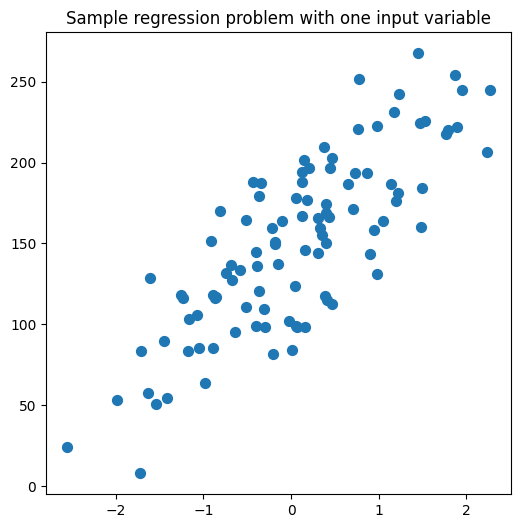

In [182]:
from sklearn.datasets import make_regression, make_classification

plt.figure(figsize=(6,6))
plt.title("Sample regression problem with one input variable")
X_R1, y_R1 = make_regression(n_samples=100, n_features=1, n_informative=1, bias=150.0, noise=30, random_state=0)
plt.scatter(X_R1, y_R1, marker='o', s=50)
plt.show()

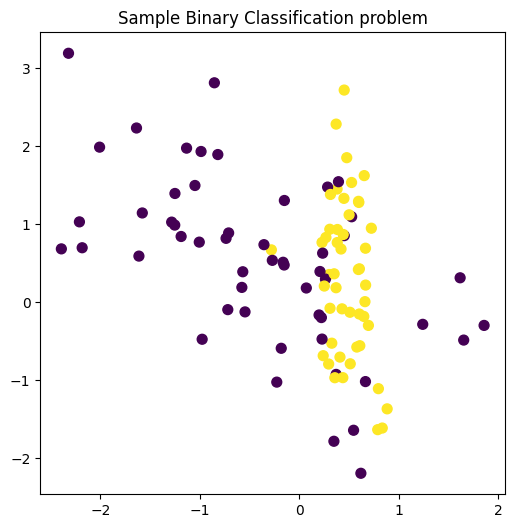

In [183]:
plt.figure(figsize=(6,6))
plt.title("Sample Binary Classification problem")
X_C1, y_C1 = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2,
                                 n_clusters_per_class=1, flip_y=0.1, class_sep=0.5, random_state=0)
plt.scatter(X_C1[:, 0], X_C1[:, 1], c=y_C1,
           marker= 'o', s=50)
plt.show()


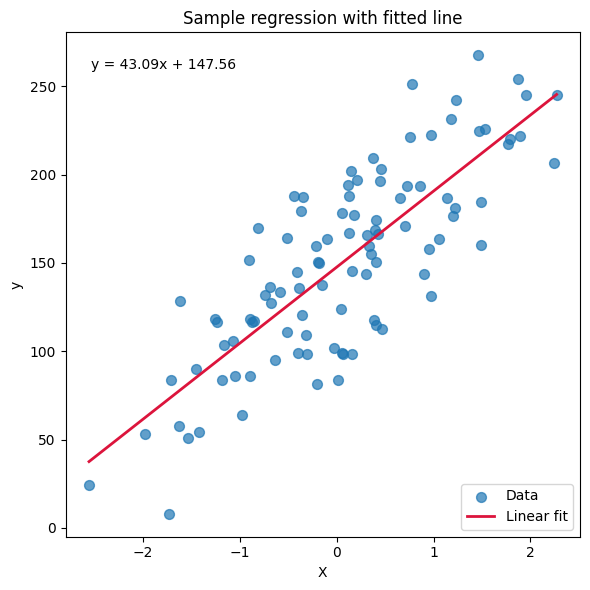

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# Your data
X_R1, y_R1 = make_regression(
    n_samples=100, n_features=1, n_informative=1,
    bias=150.0, noise=30, random_state=0
)

# Fit linear regression
linreg = LinearRegression()
linreg.fit(X_R1, y_R1)

# Prepare a grid for a smooth line
x_grid = np.linspace(X_R1.min(), X_R1.max(), 200).reshape(-1, 1)
y_pred = linreg.predict(x_grid)

# Plot scatter + fitted line
plt.figure(figsize=(6, 6))
plt.title("Sample regression with fitted line")
plt.scatter(X_R1, y_R1, marker='o', s=50, alpha=0.7, label="Data")
plt.plot(x_grid, y_pred, color="crimson", linewidth=2, label="Linear fit")

# Show equation on the plot
slope = linreg.coef_[0]
intercept = linreg.intercept_
plt.text(0.05, 0.95,
         f"y = {slope:.2f}x + {intercept:.2f}",
         transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

### KNN Regressor

In [185]:
fruits.columns

Index(['fruit_label', 'fruit_name', 'fruit_subtype', 'mass', 'width', 'height',
       'color_score'],
      dtype='object')

In [186]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import numpy as np

X_R1, y_R1 = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    bias=150.0,
    noise=30,
    random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1, random_state=42)

features = fruits[['mass', 'width', 'height']]
target = fruits['fruit_label']
X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=0)

res = []
for k in range(1,20):
    knnreg = KNeighborsRegressor(n_neighbors=k)
    knnreg.fit(X_train, y_train)
    res.append([k, knnreg.score(X_train, y_train),
                knnreg.score(X_test, y_test),
                round(knnreg.score(X_test, y_test)/knnreg.score(X_train, y_train), 3)*100])

df = pd.DataFrame(res, columns=['K value', 'Train Accuracy', 'Test Accuracy', '%'])
df

,K value,Train Accuracy,Test Accuracy,%
0,1,1.000000,-0.334746,-33.5
1,2,0.760554,-0.175847,-23.1
2,3,0.566256,0.166667,29.4
3,4,0.486642,0.491525,101.0
4,5,0.519947,0.318644,61.3
5,6,0.449758,0.194915,43.3
6,7,0.436999,0.049204,11.3
7,8,0.408188,0.049590,12.1
8,9,0.431887,0.139203,32.2
9,10,0.415026,0.118432,28.5


## Model accuracy test

In [187]:
# store all the prediction scores on training and test dataset for various models
prediction_data = [['model', 'training accuracy %', 'test accuracy %', 'alpha or k']]

In [188]:
# data preparation
from sklearn.datasets import make_regression, make_classification

# create synthetic data
X_R1, y_R1 = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    bias=150.0,
    noise=30,
    random_state=0)

# split data
X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1, random_state=42)

In [189]:
# apply MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# scaler.fit(X_train)
# X_train = scaler.transform(X_train)

# Above code can be replaced by one liner
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [190]:
# use standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [191]:
# using Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
# X_train = poly.fit_transform(X_train)
# X_test = poly.transform(X_test)

In [192]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train, y_train)
prediction_data.append(['LinearRegression', reg.score(X_train, y_train), reg.score(X_test, y_test), np.nan])
reg.score(X_train, y_train), reg.score(X_test, y_test)

(0.6134867407768969, 0.714293400992644)

In [193]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=10).fit(X_train, y_train)
prediction_data.append(['KNeighborsRegressor', knn.score(X_train, y_train), knn.score(X_test, y_test), 10])
knn.score(X_train, y_train), knn.score(X_test, y_test)

(0.6332115903345439, 0.6053148046828533)

In [194]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor().fit(X_train, y_train)
prediction_data.append(['RandomForestRegressor', rf_reg.score(X_train, y_train), rf_reg.score(X_test, y_test), np.nan])
rf_reg.score(X_train, y_train), rf_reg.score(X_test, y_test)

(0.9286976086842196, 0.49182457481170117)

In [195]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=20).fit(X_train, y_train)
prediction_data.append(['Ridge', ridge.score(X_train, y_train), ridge.score(X_test, y_test), 20])
ridge.score(X_train, y_train), ridge.score(X_test, y_test)

(0.15158224273258103, 0.14333592620011837)

In [196]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=20).fit(X_train, y_train)
prediction_data.append(['Lasso', lasso.score(X_train, y_train), lasso.score(X_test, y_test), 20])
lasso.score(X_train, y_train), lasso.score(X_test, y_test)

(0.0, -0.03171111020834294)

In [197]:
df = pd.DataFrame(data=prediction_data[1:], columns=prediction_data[0])
df['training accuracy %'] = round(df['training accuracy %']*100, 2)
df['test accuracy %'] = round(df['test accuracy %']*100, 2)
df

,model,training accuracy %,test accuracy %,alpha or k
0,LinearRegression,61.35,71.43,NaN
1,KNeighborsRegressor,63.32,60.53,10.0
2,RandomForestRegressor,92.87,49.18,NaN
3,Ridge,15.16,14.33,20.0
4,Lasso,0.00,-3.17,20.0
